<a href="https://colab.research.google.com/github/frankettheofranckettheo/Advanced-ML-Project/blob/tp2/train_model2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercice 1: Bias/Variance Analysis with Keras

In [10]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Chargement du jeu de données MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

### CORRECTION 1 : Il faut ABSOLUMENT décommenter la normalisation
# Normalisation des données (0 à 255 -> 0 à 1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Use 90% for training and 10% for validation ( dev )
# C'est correct : 60000 * 0.9 = 54000
x_val = x_train[54000:]
y_val = y_train[54000:]
x_train = x_train[:54000]
y_train = y_train[:54000]

# Redimensionnement des images pour les réseaux fully-connected
### CORRECTION 2 : Utiliser -1 ou la taille dynamique, car x_train ne fait plus 60000
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

### CORRECTION 3 : Ne pas oublier de redimensionner x_val aussi !
x_val = x_val.reshape(-1, 784)

# Construction du modèle
# Note : Pour l'Exercice 1, normalement il n'y a pas encore de Dropout.
# Mais ce n'est pas une erreur de code, juste une avance sur l'Exercice 2.
model = keras.Sequential([
  keras.layers.Dense(512, activation='relu', input_shape=(784,)),
  keras.layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

# Entrainement du modèle
history = model.fit(
  x_train,
  y_train,
  epochs=5,
  batch_size=128,
  # Ici, x_val doit avoir la forme (6000, 784) sinon ça plante
  validation_data=(x_val, y_val)
)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Précision sur les données de test: {test_acc:.4f}")

# Sauvegarde du modèle
# Assurez-vous que le dossier /content/drive/MyDrive/ existe (si vous êtes sur Colab)
model.save("mnist_model.keras")
print("Modèle sauvegardé sous mnist_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8660 - loss: 0.4809 - val_accuracy: 0.9655 - val_loss: 0.1200
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9640 - loss: 0.1242 - val_accuracy: 0.9752 - val_loss: 0.0910
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9775 - loss: 0.0783 - val_accuracy: 0.9773 - val_loss: 0.0790
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9854 - loss: 0.0525 - val_accuracy: 0.9808 - val_loss: 0.0673
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9897 - loss: 0.0381 - val_accuracy: 0.9827 - val_loss: 0.0621
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9776 - loss: 0.0768
Précision sur les données de test: 0.9797
Modèle sauvegardé sous mnist_model.keras


# Exercice 2: Applying Regularization

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8472 - loss: 0.8611 - val_accuracy: 0.9660 - val_loss: 0.2816
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9506 - loss: 0.3033 - val_accuracy: 0.9608 - val_loss: 0.2396
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9600 - loss: 0.2409 - val_accuracy: 0.9750 - val_loss: 0.1896
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9644 - loss: 0.2123 - val_accuracy: 0.9752 - val_loss: 0.1800
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9692 - loss: 0.1948 - val_accuracy: 0.9765 - val_loss: 0.1714
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9676 - loss: 0.2013
Précision sur les données de test: 0.9720
Modèle sauvegardé sous mnist_model.keras


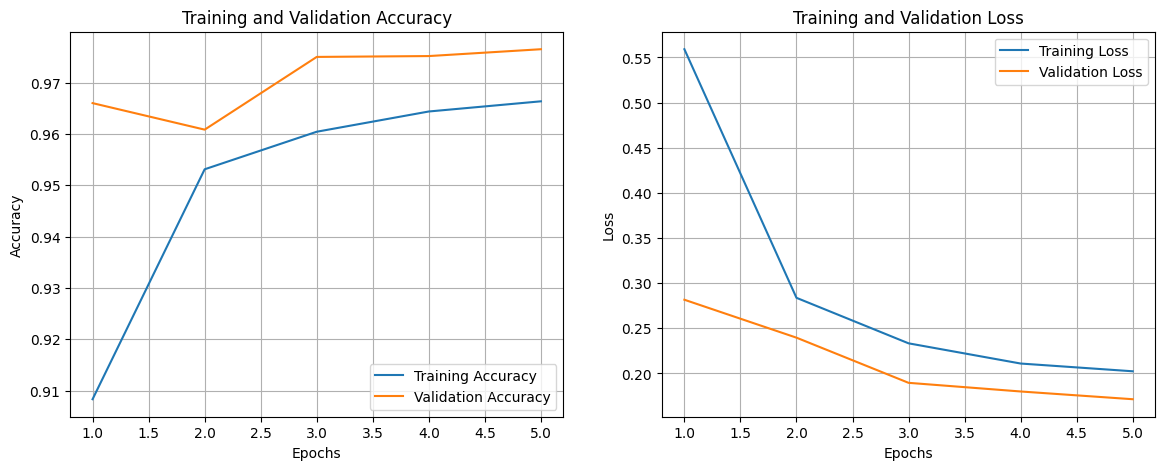

In [11]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Chargement du jeu de données MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

### CORRECTION 1 : Il faut ABSOLUMENT décommenter la normalisation
# Normalisation des données (0 à 255 -> 0 à 1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Use 90% for training and 10% for validation ( dev )
# C'est correct : 60000 * 0.9 = 54000
x_val = x_train[54000:]
y_val = y_train[54000:]
x_train = x_train[:54000]
y_train = y_train[:54000]

# Redimensionnement des images pour les réseaux fully-connected
### CORRECTION 2 : Utiliser -1 ou la taille dynamique, car x_train ne fait plus 60000
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

### CORRECTION 3 : Ne pas oublier de redimensionner x_val aussi !
x_val = x_val.reshape(-1, 784)

# Construction du modèle
# Note : Pour l'Exercice 1, normalement il n'y a pas encore de Dropout.
# Mais ce n'est pas une erreur de code, juste une avance sur l'Exercice 2.
model = keras.Sequential([
  keras.layers.Dense(512, activation='relu', input_shape=(784,), kernel_regularizer=keras.regularizers.l2(0.001)),
  keras.layers.Dropout(0.2),
  keras.layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

# Entrainement du modèle
history = model.fit(
  x_train,
  y_train,
  epochs=5,
  batch_size=128,
  # Ici, x_val doit avoir la forme (6000, 784) sinon ça plante
  validation_data=(x_val, y_val)
)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Précision sur les données de test: {test_acc:.4f}")

# Sauvegarde du modèle
# Assurez-vous que le dossier /content/drive/MyDrive/ existe (si vous êtes sur Colab)
model.save("mnist_model_one.keras")
print("Modèle sauvegardé sous mnist_model.keras")

# ==========================================
# 9. AFFICHAGE DES COURBES (NOUVEAU CODE)
# ==========================================

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Graphique 1 : Précision (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Graphique 2 : Perte (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

In [12]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.9/753.9 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.4 MB/s eta 0:00:00


# Comparing Optimizers


---> Démarrage de l'entraînement avec : SGD_with_momentum
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7585 - loss: 1.4510 - val_accuracy: 0.9348 - val_loss: 0.7846
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9203 - loss: 0.8104 - val_accuracy: 0.9513 - val_loss: 0.6576
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9354 - loss: 0.6842 - val_accuracy: 0.9575 - val_loss: 0.5663
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9442 - loss: 0.5904 - val_accuracy: 0.9658 - val_loss: 0.4883
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9537 - loss: 0.5087 - val_accuracy: 0.9678 - val_loss: 0.4297
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9576 - loss: 0.4496 - val_accuracy: 0.9695 - val_loss: 0.3793
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9625 - loss: 0.3940 - val_accuracy: 0.9723 - val_loss: 0.3411
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━

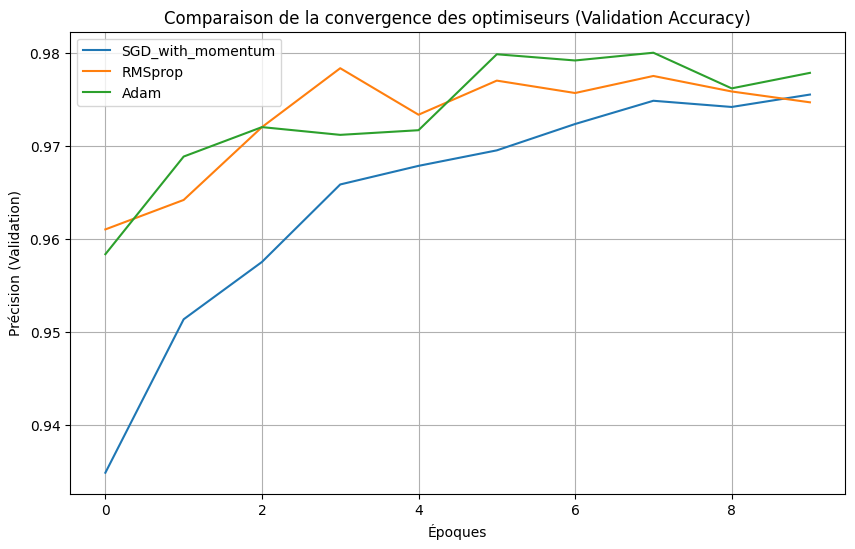

In [14]:
# !pip install mlflow  # Décommentez cette ligne pour installer mlflow si nécessaire

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.tensorflow

# 1. PRÉPARATION DES DONNÉES (Identique aux étapes précédentes)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalisation
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Split Validation/Train (10% / 90%)
x_val = x_train[54000:]
y_val = y_train[54000:]
x_train = x_train[:54000]
y_train = y_train[:54000]

# Reshape
x_train = x_train.reshape(-1, 784)
x_val = x_val.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# 2. DÉFINITION DES OPTIMISEURS
# Note: On définit SGD avec les paramètres demandés
optimizers = {
    'SGD_with_momentum': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': 'rmsprop',
    'Adam': 'adam'
}

# Dictionnaire pour stocker les historiques afin de les tracer à la fin
all_histories = {}

# Configuration de l'expérience MLflow
mlflow.set_experiment("TP2_Exercise3_Optimizers")

# 3. BOUCLE D'ENTRAÎNEMENT
for opt_name, optimizer in optimizers.items():
    print(f"\n---> Démarrage de l'entraînement avec : {opt_name}")

    with mlflow.start_run(run_name=f"Optimizer_Comparison_{opt_name}"):

        # A. RECRÉATION DU MODÈLE (Pour repartir de zéro à chaque fois)
        # On garde la structure de l'exercice 2 (avec régularisation)
        model = keras.Sequential([
            keras.layers.Dense(512, activation='relu', input_shape=(784,),
                               kernel_regularizer=keras.regularizers.l2(0.001)),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(10, activation='softmax')
        ])

        # B. COMPILATION (Avec l'optimiseur courant de la boucle)
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Log des paramètres
        mlflow.log_param("optimizer", opt_name)
        mlflow.log_param("epochs", 10)
        mlflow.log_param("batch_size", 128)

        # C. ENTRAÎNEMENT
        # On réduit un peu les epochs (ex: 10) car on va le faire 3 fois
        history = model.fit(
            x_train, y_train,
            epochs=10,
            batch_size=128,
            validation_data=(x_val, y_val),
            verbose=1
        )

        # Sauvegarde de l'historique pour le graphique comparatif
        all_histories[opt_name] = history

        # D. ÉVALUATION
        test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
        print(f"   Résultat {opt_name} -> Test Accuracy: {test_acc:.4f}")

        # E. LOG DES MÉTRIQUES FINALES DANS MLFLOW
        mlflow.log_metric("final_test_accuracy", test_acc)
        mlflow.log_metric("final_test_loss", test_loss)

        # Astuce : On peut logger la courbe de loss point par point si on veut
        # (MLflow autolog le fait souvent automatiquement, mais voici la méthode manuelle)
        for epoch, loss in enumerate(history.history['val_loss']):
            mlflow.log_metric("val_loss_history", loss, step=epoch)

# 4. COMPARAISON VISUELLE (Conclusion de l'exercice)
plt.figure(figsize=(10, 6))

for opt_name, history in all_histories.items():
    # On trace la précision de validation pour comparer la vitesse de convergence
    plt.plot(history.history['val_accuracy'], label=f"{opt_name}")

plt.title('Comparaison de la convergence des optimiseurs (Validation Accuracy)')
plt.xlabel('Époques')
plt.ylabel('Précision (Validation)')
plt.legend()
plt.grid(True)
plt.show()

# Exercice 4: Batch Normalization

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8791 - loss: 0.7942 - val_accuracy: 0.9655 - val_loss: 0.3429
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9655 - loss: 0.3065 - val_accuracy: 0.9728 - val_loss: 0.2382
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9743 - loss: 0.2179 - val_accuracy: 0.9702 - val_loss: 0.2128
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9754 - loss: 0.1836 - val_accuracy: 0.9738 - val_loss: 0.1910
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9752 - loss: 0.1795 - val_accuracy: 0.9727 - val_loss: 0.1913
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9678 - loss: 0.1994
Précision sur les données de test: 0.9724


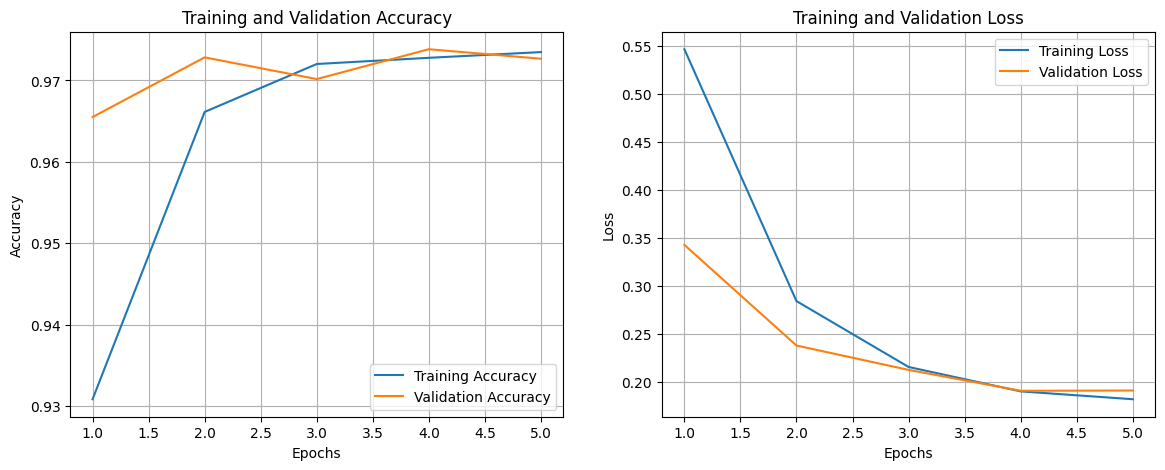

In [15]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Chargement du jeu de données MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

### CORRECTION 1 : Il faut ABSOLUMENT décommenter la normalisation
# Normalisation des données (0 à 255 -> 0 à 1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Use 90% for training and 10% for validation ( dev )
# C'est correct : 60000 * 0.9 = 54000
x_val = x_train[54000:]
y_val = y_train[54000:]
x_train = x_train[:54000]
y_train = y_train[:54000]

# Redimensionnement des images pour les réseaux fully-connected
### CORRECTION 2 : Utiliser -1 ou la taille dynamique, car x_train ne fait plus 60000
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

### CORRECTION 3 : Ne pas oublier de redimensionner x_val aussi !
x_val = x_val.reshape(-1, 784)

# Construction du modèle
# Note : Pour l'Exercice 1, normalement il n'y a pas encore de Dropout.
# Mais ce n'est pas une erreur de code, juste une avance sur l'Exercice 2.
model = keras.Sequential([
  keras.layers.Dense(512, activation='relu', input_shape=(784,), kernel_regularizer=keras.regularizers.l2(0.001)),
  keras.layers.BatchNormalization(),
  keras.layers.Dropout(0.2),
  keras.layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

# Entrainement du modèle
history = model.fit(
  x_train,
  y_train,
  epochs=5,
  batch_size=128,
  # Ici, x_val doit avoir la forme (6000, 784) sinon ça plante
  validation_data=(x_val, y_val)
)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Précision sur les données de test: {test_acc:.4f}")

# Sauvegarde du modèle
# Assurez-vous que le dossier /content/drive/MyDrive/ existe (si vous êtes sur Colab)
# model.save("mnist_model_one.keras")
# print("Modèle sauvegardé sous mnist_model.keras")

# ==========================================
# 9. AFFICHAGE DES COURBES (NOUVEAU CODE)
# ==========================================

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Graphique 1 : Précision (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Graphique 2 : Perte (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()